In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('registros_tiempos_costos.csv')
df.head()
df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y')
df = df.sort_values(['proyecto_id', 'fecha']).reset_index(drop=True)
df.dtypes

registro_id              int64
proyecto_id              int64
proyecto                   str
departamento               str
empleado_id              int64
empleado                   str
rol                        str
fecha           datetime64[us]
tarea                      str
horas                  float64
tarifa_hora              int64
costo                  float64
presupuesto              int64
dtype: object

In [3]:
horas_por_rol = df.groupby('rol')['horas'].sum().sort_values(ascending=False)
horas_por_rol

rol
Frontend    738.9
Data/ML     708.8
Backend     679.5
QA          668.9
Name: horas, dtype: float64

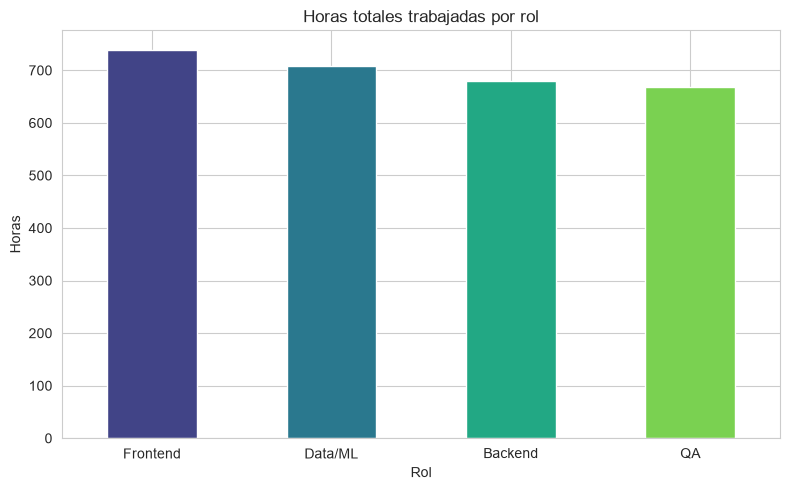

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
horas_por_rol.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', len(horas_por_rol)))
ax.set_title('Horas totales trabajadas por rol')
ax.set_xlabel('Rol')
ax.set_ylabel('Horas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Las horas entre los 4 roles parecen estar bien distribuidas y son casi similares, con una dif. de <70 hrs desde Frontend (que acumula mas hotas) hasta QA (que acumula menos horas); sugiriendo que la carga de trabajo es pareja y que un sobrecosto en algún proyecto probablemente no viene de que un solo rol esté saturado.

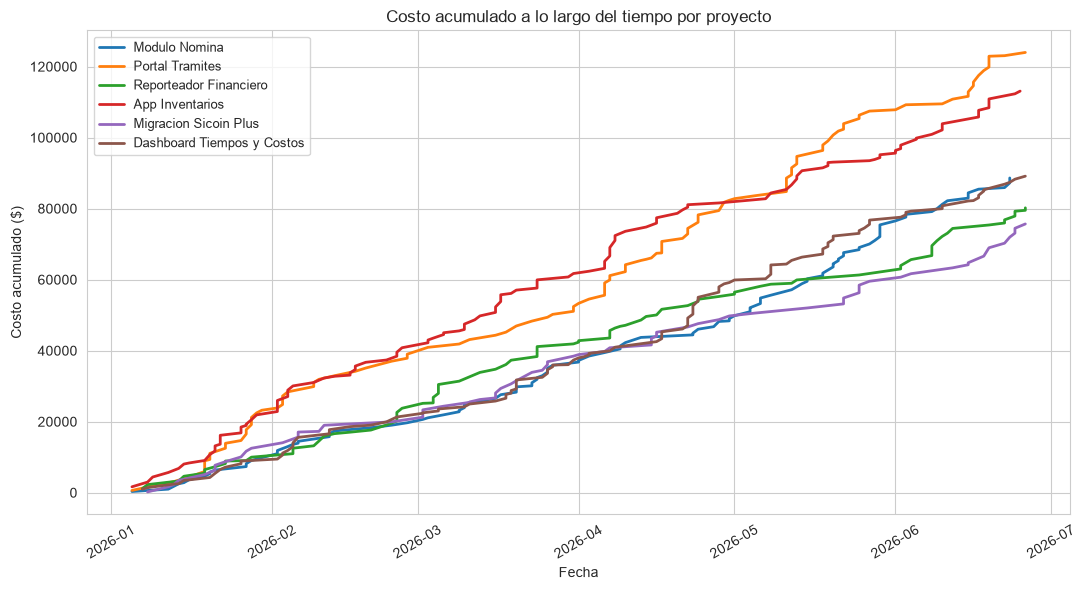

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

for pid, grupo in df.groupby('proyecto_id'):
    grupo = grupo.sort_values('fecha')
    costo_acumulado = grupo['costo'].cumsum()
    nombre = grupo['proyecto'].iloc[0]
    ax.plot(grupo['fecha'], costo_acumulado, label=nombre, linewidth=2)

ax.set_title('Costo acumulado a lo largo del tiempo por proyecto')
ax.set_xlabel('Fecha')
ax.set_ylabel('Costo acumulado ($)')
ax.legend(fontsize=9, loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Aquí se puede ver cómo cada proyecto acumula costo a un ritmo distinto a lo largo del tiempo. Algunos crecen de forma más constante, mientras que otros muestran aceleraciones a la mitad del periodo, esos cambios de pendiente son lo que después vamos a tratar de capturar como _features_ para el modelo de predicción.

In [6]:
resumen_proyectos = df.groupby(['proyecto_id', 'proyecto', 'presupuesto']).agg(
    costo_total=('costo', 'sum')
).reset_index()

resumen_proyectos

,proyecto_id,proyecto,presupuesto,costo_total
0,1,Modulo Nomina,100000,88618.0
1,2,Portal Tramites,100000,123970.0
2,3,Reporteador Financiero,95000,80205.5
3,4,App Inventarios,100000,113083.0
4,5,Migracion Sicoin Plus,60000,75671.0
5,6,Dashboard Tiempos y Costos,110000,89131.5


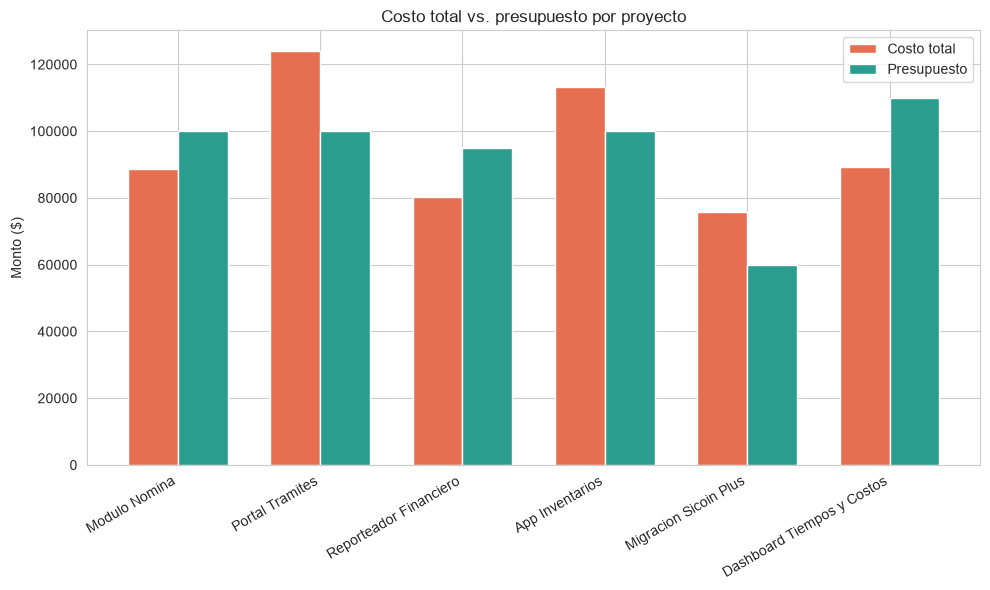

In [7]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(resumen_proyectos))
width = 0.35

ax.bar(x - width/2, resumen_proyectos['costo_total'], width, label='Costo total', color='#e76f51')
ax.bar(x + width/2, resumen_proyectos['presupuesto'], width, label='Presupuesto', color='#2a9d8f')

ax.set_xticks(x)
ax.set_xticklabels(resumen_proyectos['proyecto'], rotation=30, ha='right')
ax.set_ylabel('Monto ($)')
ax.set_title('Costo total vs. presupuesto por proyecto')
ax.legend()
plt.tight_layout()
plt.show()

Migración Sicoin Plus es el caso más notorio: tenía el presupuesto más bajo de todos ($60,000) y terminó con un costo similar al de proyectos con presupuestos casi el doble (Dashboard y Módulo Nómina). Esto sugiere que el presupuesto inicial pudo haber sido subestimado desde el arranque, más que un problema de ejecución tardía o descontrol durante el proyecto.

In [8]:
resumen_final = df.groupby('proyecto_id').agg(
    costo_total=('costo', 'sum'),
    presupuesto=('presupuesto', 'first')
).reset_index()
resumen_final['excedio'] = (resumen_final['costo_total'] > resumen_final['presupuesto']).astype(int)
resumen_final

,proyecto_id,costo_total,presupuesto,excedio
0,1,88618.0,100000,0
1,2,123970.0,100000,1
2,3,80205.5,95000,0
3,4,113083.0,100000,1
4,5,75671.0,60000,1
5,6,89131.5,110000,0


In [9]:
filas = []

for pid, grupo in df.groupby('proyecto_id'):
    grupo = grupo.sort_values('fecha').reset_index(drop=True)
    n = len(grupo)
    presupuesto = grupo['presupuesto'].iloc[0]
    label = resumen_final.loc[resumen_final.proyecto_id == pid, 'excedio'].values[0]

    for frac in [0.3, 0.5, 0.7]:
        corte = int(n * frac)
        sub = grupo.iloc[:corte]

        dias_transcurridos = (sub['fecha'].max() - sub['fecha'].min()).days + 1
        horas_acum = sub['horas'].sum()
        costo_acum = sub['costo'].sum()

        filas.append({
            'proyecto_id': pid,
            'corte_pct': frac,
            'horas_acumuladas': horas_acum,
            'costo_acumulado': costo_acum,
            'pct_presupuesto_usado': costo_acum / presupuesto,
            'ritmo_gasto_diario': costo_acum / dias_transcurridos,
            'costo_promedio_por_hora': costo_acum / horas_acum,
            'n_empleados_distintos': sub['empleado_id'].nunique(),
            'n_roles_distintos': sub['rol'].nunique(),
            'excedio': label
        })

features_df = pd.DataFrame(filas)
features_df

,proyecto_id,corte_pct,horas_acumuladas,costo_acumulado,pct_presupuesto_usado,ritmo_gasto_diario,costo_promedio_por_hora,n_empleados_distintos,n_roles_distintos,excedio
0,1,0.3,124.4,23193.0,0.231930,362.390625,186.438907,3,3,0
1,1,0.5,219.1,40483.0,0.404830,426.136842,184.769512,3,3,0
2,1,0.7,315.6,58851.5,0.588515,452.703846,186.474968,3,3,0
3,2,0.3,185.4,40925.5,0.409255,705.612069,220.741640,5,4,1
4,2,0.5,303.3,65713.0,0.657130,657.130000,216.660073,5,4,1
5,2,0.7,416.4,89518.0,0.895180,699.359375,214.980788,5,4,1
6,3,0.3,99.9,22591.5,0.237805,451.830000,226.141141,4,3,0
7,3,0.5,187.3,41894.5,0.440995,498.744048,223.675921,4,3,0
8,3,0.7,253.3,55891.0,0.588326,486.008696,220.651402,4,3,0
9,4,0.3,170.6,33744.0,0.337440,784.744186,197.796014,3,3,1


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix

In [11]:
feature_cols = ['horas_acumuladas', 'costo_acumulado', 'pct_presupuesto_usado',
                'ritmo_gasto_diario', 'costo_promedio_por_hora',
                'n_empleados_distintos', 'n_roles_distintos']

X = features_df[feature_cols]
y = features_df['excedio']

X.shape, y.shape

((18, 7), (18,))

In [12]:
loo = LeaveOneOut()

for nombre, modelo in [('Regresión Logística', LogisticRegression(max_iter=1000)),
                        ('Árbol de Decisión', DecisionTreeClassifier(max_depth=3, random_state=42))]:

    predicciones = []
    reales = []

    for train_idx, test_idx in loo.split(X):
        modelo.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = modelo.predict(X.iloc[test_idx])
        predicciones.extend(pred)
        reales.extend(y.iloc[test_idx])

    acc = accuracy_score(reales, predicciones)
    print(f"{nombre}: accuracy = {acc:.2%}")
    print(confusion_matrix(reales, predicciones))
    print()

/Users/ntmyrice/Documents/Prueba_Mau/reto-tecnico/analisis-datos/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/ntmyrice/Documents/Prueba_Mau/reto-tecnico/analisis-datos/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might al

Regresión Logística: accuracy = 88.89%
[[9 0]
 [2 7]]

Árbol de Decisión: accuracy = 100.00%
[[9 0]
 [0 9]]



In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

modelo_log = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

In [14]:
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
grupos = features_df['proyecto_id']

for nombre, modelo in [('Regresión Logística', modelo_log),
                        ('Árbol de Decisión', DecisionTreeClassifier(max_depth=3, random_state=42))]:

    predicciones = []
    reales = []

    for train_idx, test_idx in logo.split(X, y, groups=grupos):
        modelo.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = modelo.predict(X.iloc[test_idx])
        predicciones.extend(pred)
        reales.extend(y.iloc[test_idx])

    acc = accuracy_score(reales, predicciones)
    print(f"{nombre}: accuracy = {acc:.2%}")
    print(confusion_matrix(reales, predicciones))
    print()

Regresión Logística: accuracy = 33.33%
[[3 6]
 [6 3]]

Árbol de Decisión: accuracy = 50.00%
[[6 3]
 [6 3]]



## Modelo de clasificación:

**Features:** Para cada proyecto, se tomaron 3 cortes temporales (al 30%, 50% y 70% de sus registros), y se calcularon 7 variables usando solo los datos disponibles hasta ese punto: horas acumuladas, costo acumulado, % del presupuesto ya usado, ritmo de gasto diario, costo promedio por hora, número de empleados distintos involucrados, y número de roles distintos. Ninguna feature usa información del resultado final del proyecto, para evitar fuga de datos (data leakage).

**Modelos probados:** Regresión Logística (con escalado de datos para evitar el warning de convergencia por diferencias de escala entre features {usando `StandardScaler`}) y Árbol de Decisión (con profundidad de 3, para evitar sobreajuste por lo pequeño del dataset).

**Dos formas de validación:**

- **Leave-One-Out por fila (LOOCV):** Regresión Logística con 89% y Árbol de Decisión 100%. Apoyandome con una revisión con CLAUDE, estos números engañan "_... como cada proyecto aparece 3 veces (una por corte), el modelo puede "memorizar" el proyecto en vez de aprender un patrón real, porque los otros cortes del mismo proyecto siguen disponibles en el entrenamiento._"
- **Leave-One-Group-Out por proyecto:** Regresión Logística de 33% y Árbol de Decisión con 50%. Aquí, cuando se evalúa un proyecto, ningún dato de ese proyecto estuvo disponible en el entrenamiento "_es una medida mucho más honesta de qué tan bien generalizaría el modelo a un proyecto nuevo que nunca ha visto._"

**Conclusión de la comparación:** Con solo 6 proyectos históricos, el modelo no logra encontrar un patrón que se transfiera de forma confiable de un proyecto a otro completamente distinto (el resultado agrupado del 33-50% es cercano a adivinar). Esto no invalida el enfoque; simplemente refleja que 6 proyectos son insuficientes para entrenar un modelo que generalice bien. Con un dataset real más grande (20+ proyectos), la validación por `LeaveOneGroupOut` seguiría siendo la correcta, pero con más grupos el modelo tendría más oportunidad de aprender un patrón genuino.

In [15]:
modelo_final = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_final.fit(X, y)

importancias = pd.Series(modelo_final.feature_importances_, index=feature_cols).sort_values(ascending=False)
importancias

ritmo_gasto_diario         0.5
n_roles_distintos          0.5
horas_acumuladas           0.0
costo_acumulado            0.0
pct_presupuesto_usado      0.0
costo_promedio_por_hora    0.0
n_empleados_distintos      0.0
dtype: float64

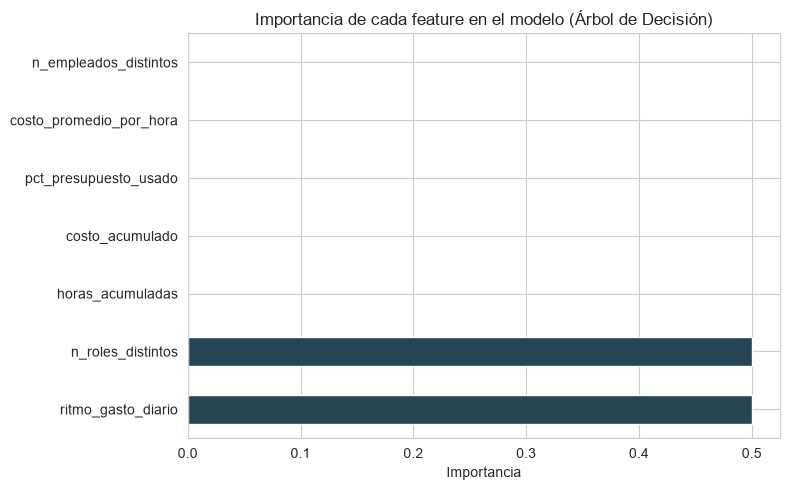

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind='barh', ax=ax, color='#264653')
ax.set_title('Importancia de cada feature en el modelo (Árbol de Decisión)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

El Árbol de Decisión concentró toda su capacidad predictiva en solo 2 de las 7 features (`ritmo_gasto_diario` y `n_roles_distintos`), dejando las otras 5 (incluyendo `pct_presupuesto_usado`, que parecería la más relevante) en cero. Esto refuerza la conclusión de que con tan pocas muestras, el árbol prefirió un atajo para distinguir los proyectos que ya conocía, en vez de aprender qué variables realmente explican un sobrecosto.

Con más datos históricos, se esperaría ver una distribución de importancia más repartida y más alineada con la intuición de negocio (como ejemplo, que el % de presupuesto usado pese más).

## Conclusiones y limitaciones

**Hallazgos principales:**
- De los 6 proyectos analizados, 3 excedieron su presupuesto (Portal Trámites, App Inventarios, Migración Sicoin Plus) y 3 se mantuvieron dentro.
- Los proyectos que terminan excediendo ya muestran un % de presupuesto usado más alto desde etapas tempranas (30% de avance), comparado con los que no exceden — una señal temprana con potencial real de negocio.
- El proyecto _Migración Sicoin Plus_ es un caso particular: tenía el presupuesto más bajo de todos, lo que sugiere que el problema pudo ser una subestimación inicial más que un descontrol durante la ejecución.
- Las horas trabajadas están razonablemente balanceadas entre los 4 roles del equipo, así que el sobrecosto no parece originarse en un solo rol saturado.

**Sobre el modelo de clasificación:**
- Con la validación LOOCV por fila, los modelos alcanzan un accuracy alto (89% Regresión Logística, 100% Árbol de Decisión), pero ese número es una trampa: como cada proyecto aparece 3 veces (una por corte temporal), _el modelo puede memorizar el proyecto en vez de aprender un patrón generalizable_, porque los otros cortes del mismo proyecto siguen disponibles en el entrenamiento.
- Con validación LeaveOneGroupOut (agrupando por proyecto), la accuracy cae a 33% (Regresión Logística) y 50% en Árbol de Decisión. Aquí, cuando se evalúa un proyecto, ningún dato de ese proyecto estuvo disponible en el entrenamiento, así que es una medida mucho más honesta de qué tan bien se adaptaría el modelo a un proyecto nuevo que nunca ha visto.
- Esto refleja una limitación real de los datos, no un error de implementación: 6 proyectos son **insuficientes** para entrenar un modelo que generalice de forma confiable a un proyecto completamente nuevo. Con un dataset real más grande (>20 proyectos), la validación por `LeaveOneGroupOut` seguiría siendo la correcta, pero con más grupos el modelo tendría más oportunidad de aprender un patrón genuino.

**Limitaciones de este análisis:**
- El dataset tiene solo 6 proyectos, por lo que cualquier conclusión estadística debe tomarse con pinzas.
- Las 18 muestras usadas para entrenar vienen de esos mismos 6 proyectos (vía cortes temporales), así que no son verdaderamente independientes entre sí.
- No se probaron modelos más complejos (Random Forest, XGBoost) porque con este tamaño de dataset, un modelo complejo solo aumentaría el riesgo de sobreajuste sin aportar nada real, por ello un modelo simple e interpretable es la decisión más honesta aquí.

**Qué haría con más tiempo:**
- Conseguir más proyectos históricos para tener una muestra más robusta y confiable.
- Explorar si categorizar las tareas por tipo (desarrollo, pruebas, reuniones, documentación) aporta como feature adicional.
- Si se consigue más data, comparar contra modelos más complejos una vez que el tamaño de muestra lo justifique.